Please upload Employee_Salary_Dataset.csv or archive.zip


Saving archive.zip to archive.zip

Uploaded file: archive.zip

CSV file loaded successfully!

Column Names:
Index(['ID', 'Experience_Years', 'Age', 'Gender', 'Salary'], dtype='object')

First 5 Rows:
   ID  Experience_Years  Age  Gender  Salary
0   1                 5   28  Female  250000
1   2                 1   21    Male   50000
2   3                 3   23  Female  170000
3   4                 2   22    Male   25000
4   5                 1   17    Male   10000

Shape of Dataset:
(35, 5)

Data Types:
ID                   int64
Experience_Years     int64
Age                  int64
Gender              object
Salary               int64
dtype: object

Employees with Salary greater than 50000:
    ID  Experience_Years  Age  Gender    Salary
0    1                 5   28  Female    250000
2    3                 3   23  Female    170000
5    6                25   62    Male   5001000
6    7                19   54  Female    800000
8    9                10   36  Female     61500
9   10    

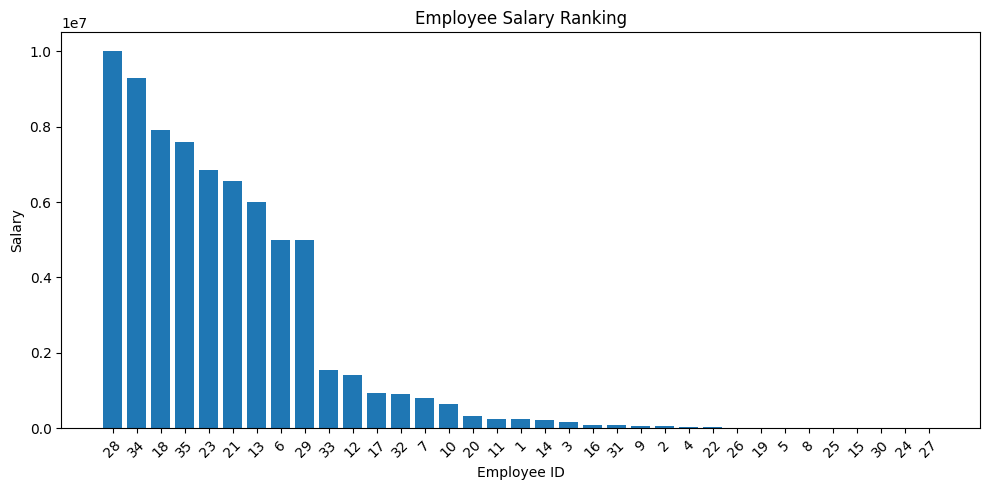


Statistical Analysis of Salary:
Mean = 2059147.14
Median = 250000.0
Mode = [25000, 250000]
Standard Deviation = 3170123.64

Descriptive Statistics:
              ID  Experience_Years        Age        Salary
count  35.000000          35.00000  35.000000  3.500000e+01
mean   18.000000           9.20000  35.485714  2.059147e+06
std    10.246951           7.55295  14.643552  3.170124e+06
min     1.000000           1.00000  17.000000  3.000000e+03
25%     9.500000           2.50000  22.500000  2.250000e+04
50%    18.000000           6.00000  29.000000  2.500000e+05
75%    26.500000          15.00000  53.500000  3.270000e+06
max    35.000000          27.00000  62.000000  1.000000e+07

Average Salary by Gender:
Gender
Female    2.054917e+06
Male      2.063626e+06
Name: Salary, dtype: float64


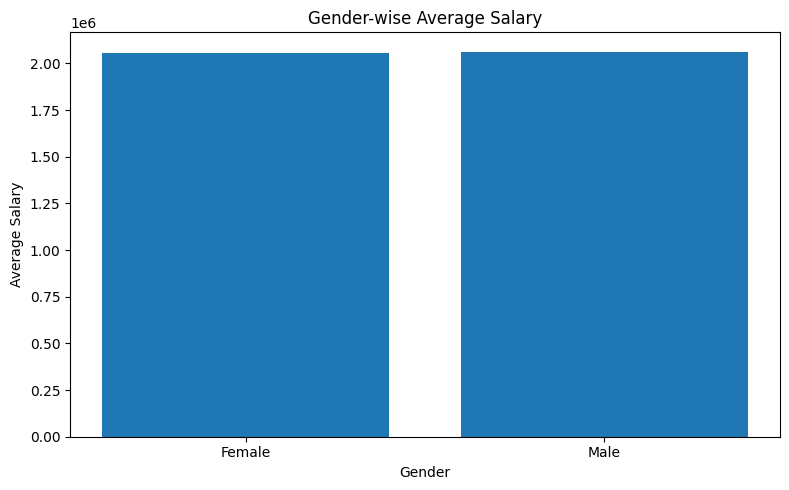


Correlation Matrix:
                        ID  Experience_Years       Age    Salary
ID                1.000000          0.291098  0.282452  0.362092
Experience_Years  0.291098          1.000000  0.973708  0.685600
Age               0.282452          0.973708  1.000000  0.668444
Salary            0.362092          0.685600  0.668444  1.000000


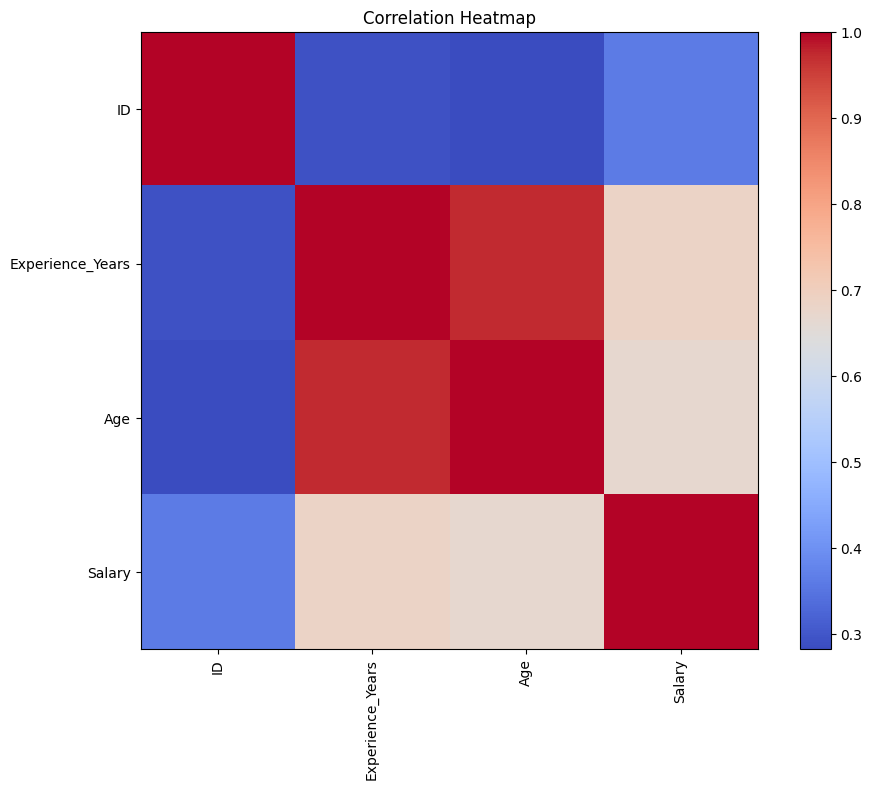

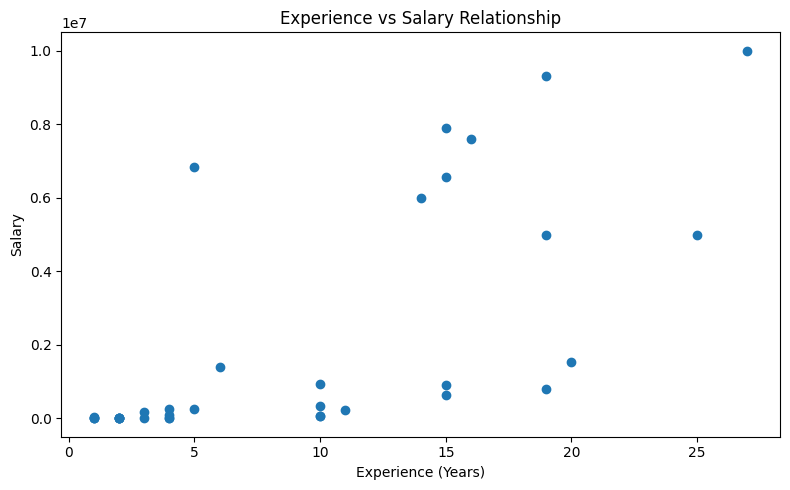

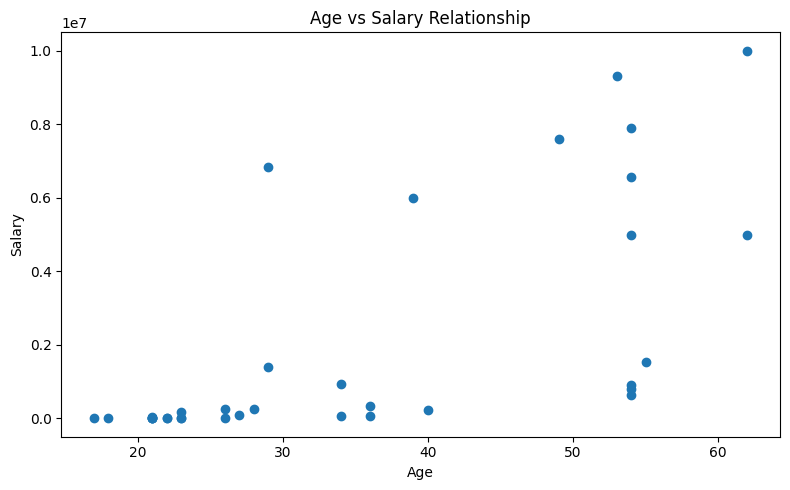


EXPERIMENT 4 COMPLETED SUCCESSFULLY
Data inspection completed.
Data filtering completed.
Data sorting completed.
Statistical analysis completed.
Grouping and aggregation completed.
Correlation analysis completed.
Data visualization completed.


In [1]:
# ============================================================
# EXPERIMENT 4 - EDA
# DATA INSPECTION, FILTERING, STATISTICAL ANALYSIS
# AND CORRELATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import glob

from google.colab import files


# ============================================================
# UPLOAD DATASET
# ============================================================

print("Please upload Employee_Salary_Dataset.csv or archive.zip")

uploaded = files.upload()

uploaded_file = list(uploaded.keys())[0]

print("\nUploaded file:", uploaded_file)


# ============================================================
# LOAD CSV FILE
# ============================================================

if uploaded_file.endswith(".zip"):

    with zipfile.ZipFile(uploaded_file, "r") as zip_ref:
        zip_ref.extractall("data")

    csv_files = glob.glob(
        "data/**/*.csv",
        recursive=True
    )

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No CSV file found inside the ZIP file."
        )

    csv_file = csv_files[0]

else:

    csv_file = uploaded_file


df = pd.read_csv(csv_file)

print("\nCSV file loaded successfully!")


# ============================================================
# PROGRAM 1 - DATASET INSPECTION
# ============================================================

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# PROGRAM 2 - SHAPE OF DATASET
# ============================================================

print("\nShape of Dataset:")
print(df.shape)


# ============================================================
# PROGRAM 3 - DATA TYPES
# ============================================================

print("\nData Types:")
print(df.dtypes)


# ============================================================
# PROGRAM 4 - FILTERING
# Employees with Salary greater than 50000
# ============================================================

high_salary = df[
    df["Salary"] > 50000
]

print("\nEmployees with Salary greater than 50000:")
print(high_salary)


# ============================================================
# PROGRAM 5 - FILTERING
# Employees with Experience greater than 5 years
# ============================================================

experienced = df[
    df["Experience_Years"] > 5
]

print("\nEmployees with Experience greater than 5 years:")
print(experienced)


# ============================================================
# PROGRAM 6 - SORTING
# Salary in Descending Order
# ============================================================

sorted_df = df.sort_values(
    by="Salary",
    ascending=False
)

print("\nEmployees Sorted by Salary:")
print(sorted_df)


# ============================================================
# VISUALIZATION - EMPLOYEE SALARY RANKING
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    sorted_df["ID"].astype(str),
    sorted_df["Salary"]
)

plt.xlabel("Employee ID")

plt.ylabel("Salary")

plt.title("Employee Salary Ranking")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ============================================================
# PROGRAM 7 - STATISTICAL ANALYSIS
# ============================================================

print("\nStatistical Analysis of Salary:")

print(
    "Mean =",
    round(df["Salary"].mean(), 2)
)

print(
    "Median =",
    round(df["Salary"].median(), 2)
)

print(
    "Mode =",
    df["Salary"].mode().tolist()
)

print(
    "Standard Deviation =",
    round(df["Salary"].std(), 2)
)


# ============================================================
# PROGRAM 8 - DESCRIPTIVE STATISTICS
# ============================================================

print("\nDescriptive Statistics:")

print(df.describe())


# ============================================================
# PROGRAM 9 - GROUPING AND AGGREGATION
# Average Salary by Gender
# ============================================================

gender_avg = df.groupby(
    "Gender"
)["Salary"].mean()

print("\nAverage Salary by Gender:")

print(gender_avg)


# ============================================================
# VISUALIZATION - GENDER-WISE AVERAGE SALARY
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    gender_avg.index,
    gender_avg.values
)

plt.xlabel("Gender")

plt.ylabel("Average Salary")

plt.title("Gender-wise Average Salary")

plt.tight_layout()

plt.show()


# ============================================================
# PROGRAM 10 - CORRELATION ANALYSIS
# ============================================================

corr = df.select_dtypes(
    include="number"
).corr()

print("\nCorrelation Matrix:")

print(corr)


# ============================================================
# VISUALIZATION - CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10,8))

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()


# ============================================================
# EXPERIENCE VS SALARY
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(
    df["Experience_Years"],
    df["Salary"]
)

plt.xlabel("Experience (Years)")

plt.ylabel("Salary")

plt.title("Experience vs Salary Relationship")

plt.tight_layout()

plt.show()


# ============================================================
# AGE VS SALARY
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(
    df["Age"],
    df["Salary"]
)

plt.xlabel("Age")

plt.ylabel("Salary")

plt.title("Age vs Salary Relationship")

plt.tight_layout()

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n================================================")
print("EXPERIMENT 4 COMPLETED SUCCESSFULLY")
print("================================================")

print("Data inspection completed.")
print("Data filtering completed.")
print("Data sorting completed.")
print("Statistical analysis completed.")
print("Grouping and aggregation completed.")
print("Correlation analysis completed.")
print("Data visualization completed.")

print("================================================")